In [82]:
!pip install pandas
!pip install scikit-learn
!pip install matplotlib

### Setup imports

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import log_loss

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV


### Load the data

In [84]:
MOMP_df_Orig = pd.read_csv('Data/MOMP_Data_KL_2019.csv')

### Preview the data

In [85]:
MOMP_df_Orig.head()

,Unnamed: 0,species,species.code,stop,date,year,occ.hist,julian.z,time.m.z,cloud.cover.z,wind.z,noise.z,snow.cover.z,precip.z,temp.z,lat.z
0,5011,Barred Owl,BARR,1,2004-03-05,2004,10110000000,-2.888471,-0.813241,0.0,0.485932,-0.59775,1.552534,-0.181054,0.40585,0.0
1,5012,Great Horned Owl,GHOW,1,2004-03-05,2004,0,-2.888471,-0.813241,0.0,0.485932,-0.59775,1.552534,-0.181054,0.40585,0.0
2,5013,Northern Saw-whet Owl,NSWO,1,2004-03-05,2004,0,-2.888471,-0.813241,0.0,0.485932,-0.59775,1.552534,-0.181054,0.40585,0.0
3,5014,Barred Owl,BARR,2,2004-03-05,2004,0,-2.888471,-0.652362,0.0,0.485932,-0.59775,0.000000,-0.181054,0.40585,0.0
4,5015,Great Horned Owl,GHOW,2,2004-03-05,2004,10000000000000,-2.888471,-0.652362,0.0,0.485932,-0.59775,0.000000,-0.181054,0.40585,0.0


In [86]:
print(MOMP_df_Orig.columns)

Index(['Unnamed: 0', 'species', 'species.code', 'stop', 'date', 'year',
       'occ.hist', 'julian.z', 'time.m.z', 'cloud.cover.z', 'wind.z',
       'noise.z', 'snow.cover.z', 'precip.z', 'temp.z', 'lat.z'],
      dtype='str')


### Create dataframe

In [87]:
features = ['wind.z', 'noise.z', 'temp.z', 'time.m.z'] # Determine the columns we're using

MOMP_df = MOMP_df_Orig[features + ['occ.hist']].dropna() # Create new dataset with just columns we will use

MOMP_df['occ.hist'] = MOMP_df['occ.hist'].apply( # This changes occ.hist from binary to either just 0 (not detected) or 1 (detected)
    lambda x: 1 if '1' in str(x) else 0
)

X = MOMP_df_Orig[features] # Separate inputs and output
y = MOMP_df_Orig['occ.hist']

X = X[:5000] # Limit to first 5000 rows
y = y[:5000]

MOMP_df.head()

,wind.z,noise.z,temp.z,time.m.z,occ.hist
0,0.485932,-0.59775,0.40585,-0.813241,1
1,0.485932,-0.59775,0.40585,-0.813241,0
2,0.485932,-0.59775,0.40585,-0.813241,0
3,0.485932,-0.59775,0.40585,-0.652362,0
4,0.485932,-0.59775,0.40585,-0.652362,1


### Train-test split

In [88]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Random Forest Classifier

In [89]:
rf = RandomForestClassifier(random_state=42)

rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}

rf_grid = GridSearchCV(rf, rf_params, cv=2)
rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


Random Forest Accuracy: 0.85


### Gradient boost

In [90]:
gb = GradientBoostingClassifier(random_state=42)

gb_params = {
    'n_estimators': [50],
    'learning_rate': [0.1],
    'max_depth': [2]
}

gb_grid = GridSearchCV(gb, gb_params, cv=2)
gb_grid.fit(X_train, y_train)

gb_best = gb_grid.best_estimator_
gb_pred = gb_best.predict(X_test)

gb_acc = accuracy_score(y_test, gb_pred)
print("Gradient Boosting Accuracy:", gb_acc)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


Gradient Boosting Accuracy: 0.746


### Neural Network

In [91]:
mlp = MLPClassifier(max_iter=500, random_state=42, verbose=False)

mlp_params = {
    'hidden_layer_sizes': [(50,), (100,)],
}

mlp_grid = GridSearchCV(mlp, mlp_params, cv=2)
mlp_grid.fit(X_train, y_train)

mlp_best = mlp_grid.best_estimator_
mlp_pred = mlp_best.predict(X_test)

mlp_acc = accuracy_score(y_test, mlp_pred)
print("Neural Network Accuracy:", mlp_acc)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neur

Neural Network Accuracy: 0.855


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


### Comparing models

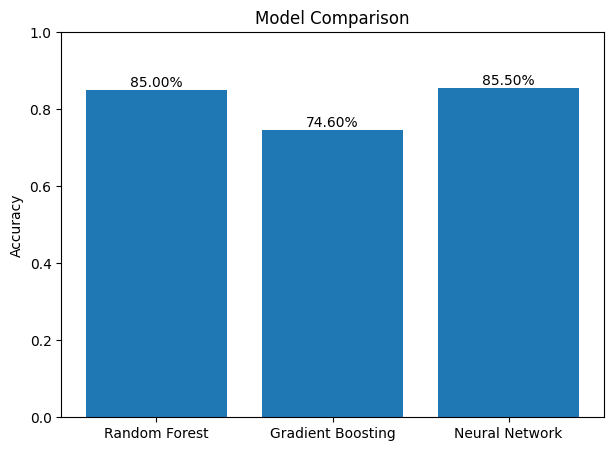

In [92]:
models = ['Random Forest', 'Gradient Boosting', 'Neural Network']
scores = [rf_acc, gb_acc, mlp_acc]

plt.figure(figsize=(7,5))
bars = plt.bar(models, scores)

plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.ylim(0, 1)

# Adding labels on top of bars
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{score:.2%}",
        ha='center',
        va='bottom'
    )

plt.show()

### Feature importances from RandomForest

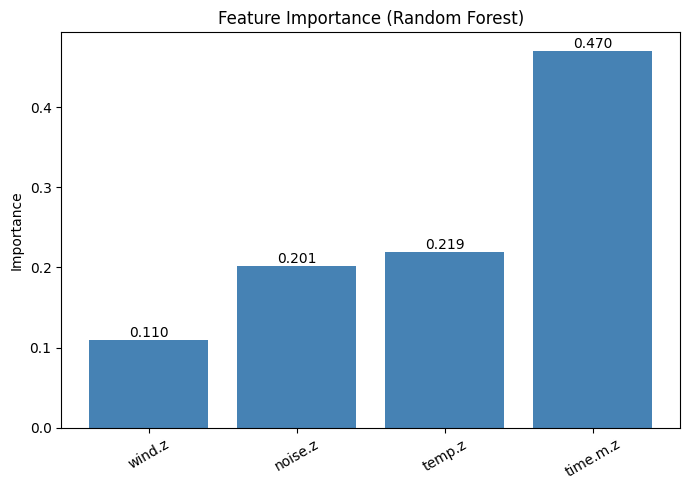

In [93]:
importances = rf_best.feature_importances_
features = X_train.columns

plt.figure(figsize=(7,5))
bars = plt.bar(features, importances, color="steelblue")

plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.xticks(rotation=30)

# Adding values on top of bars
for bar, imp in zip(bars, importances):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{imp:.3f}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

### Neural network loss curve

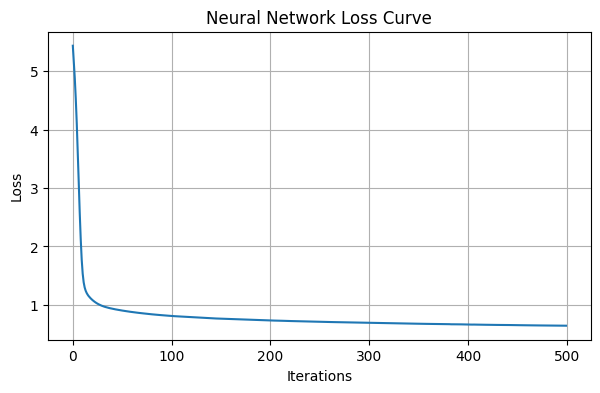

In [95]:
plt.figure(figsize=(7,4))
plt.plot(mlp_best.loss_curve_)

plt.title("Neural Network Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

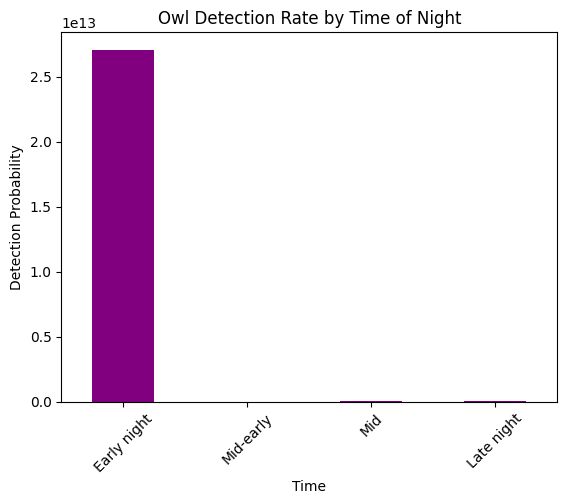

In [100]:
temp_df = X_test.copy()
temp_df['occ.hist'] = y_test

temp_df['time_bin'] = pd.cut(temp_df['time.m.z'], bins=5, labels=[
    "Early night",
    "Mid-early",
    "Mid",
    "Mid-late",
    "Late night"
])

grouped = temp_df.groupby('time_bin')['occ.hist'].mean()

grouped.plot(kind='bar', color='purple')

plt.title("Owl Detection Rate by Time of Night")
plt.xlabel("Time")
plt.ylabel("Detection Probability")
plt.xticks(rotation=45)
plt.show()